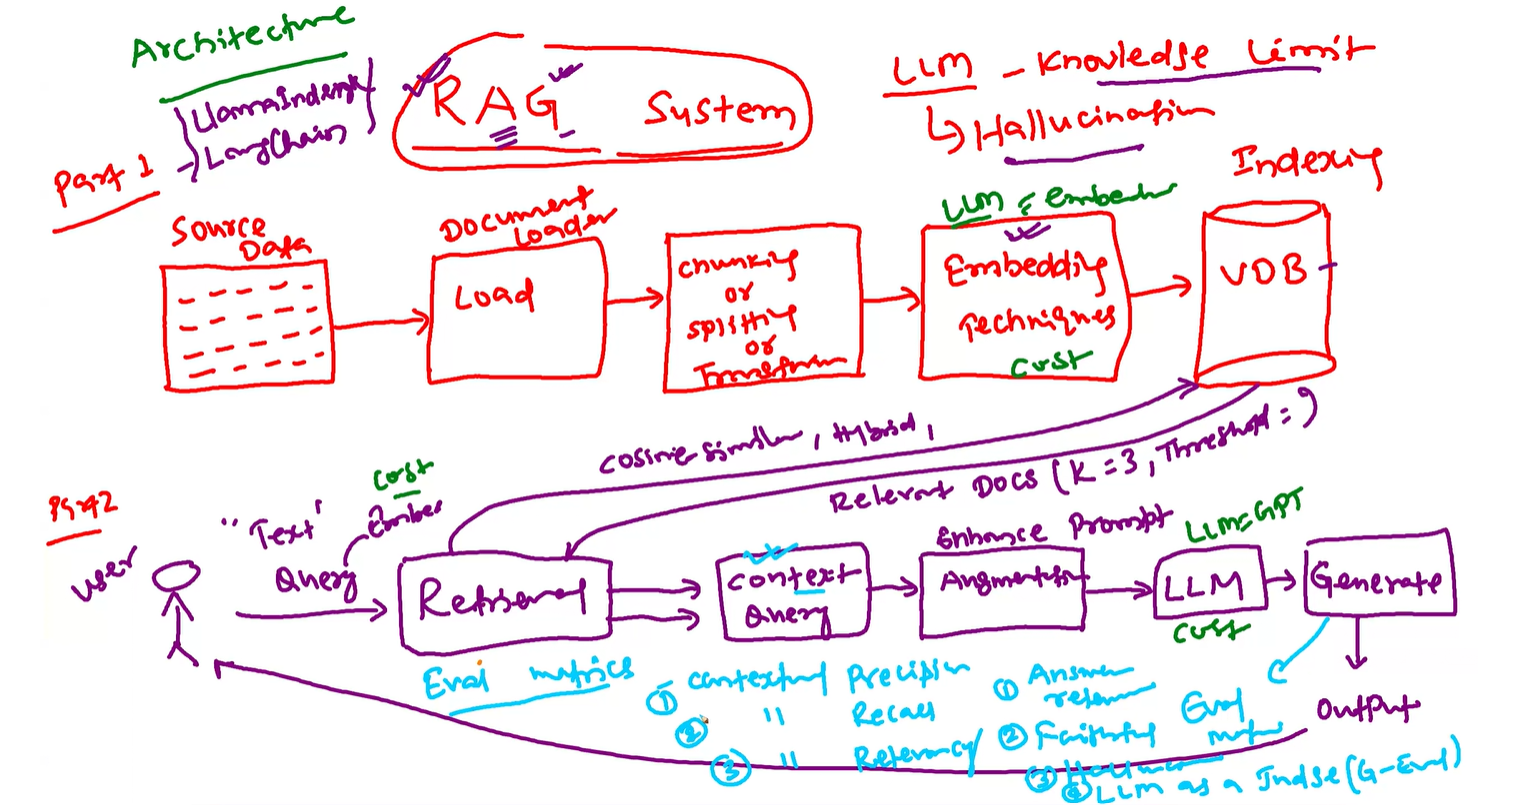

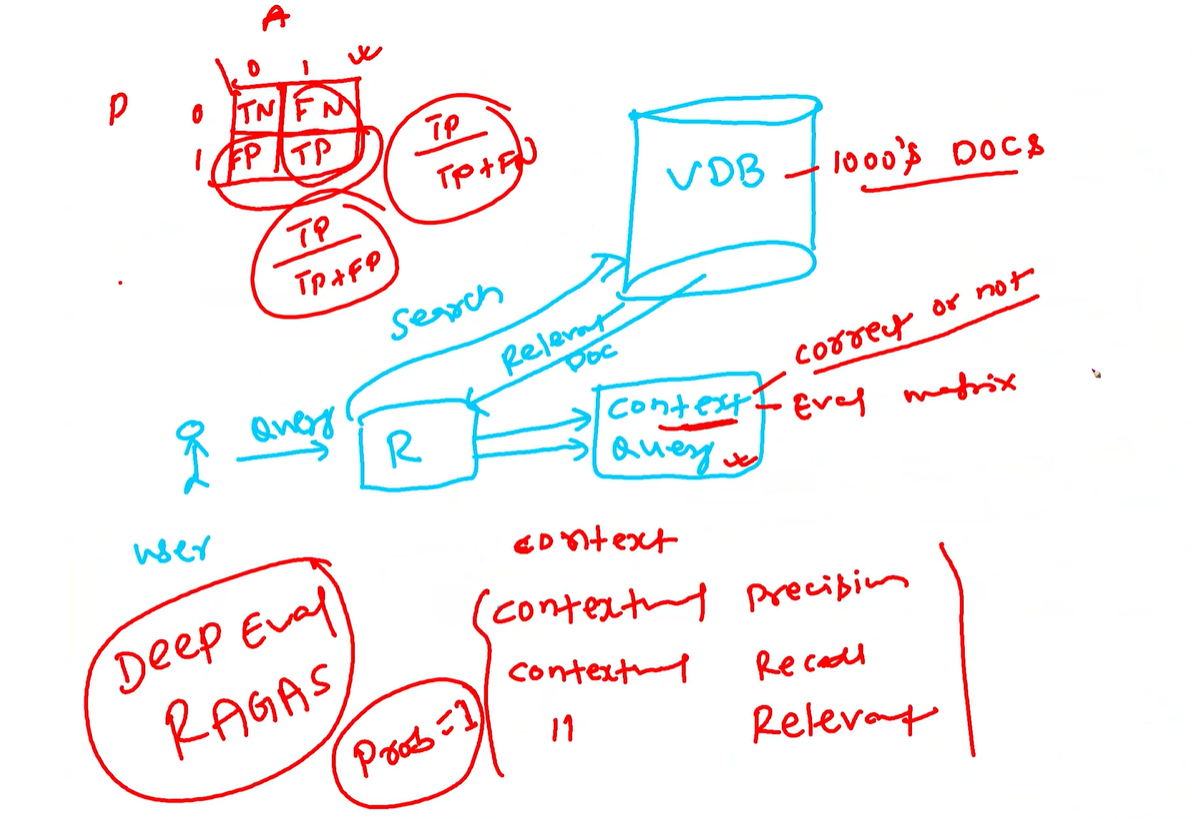

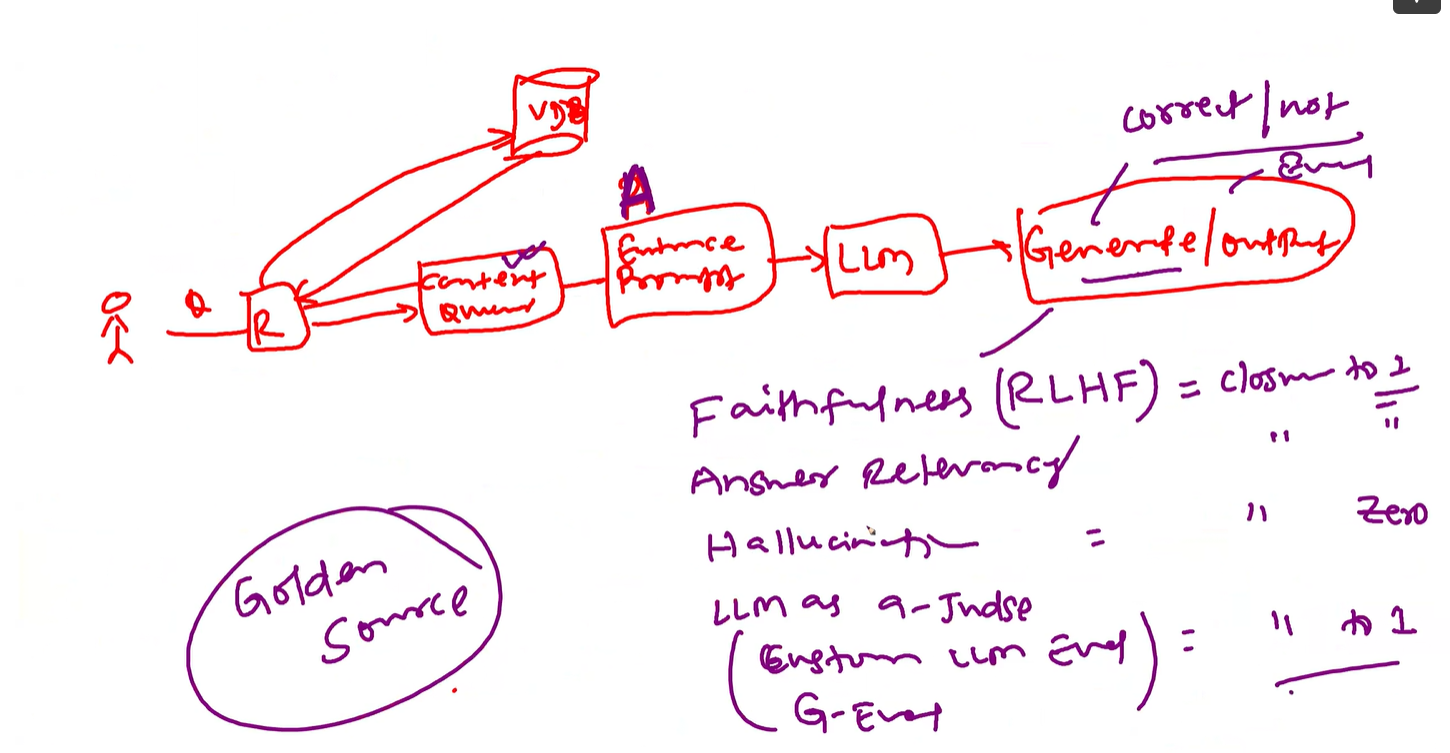

## Building RAG system with Evaluation Metrics

In [2]:
# %pip install ragas deepeval

In [7]:
import pandas as pd
import os

In [23]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

### Load Data from CSV

In [4]:
df = pd.read_csv('../Datasets/rag_eval_docs.csv')
df

,id,title,context
0,1,Machine Learning,Machine learning is a field of artificial inte...
1,2,Deep Learning,Deep learning is a subset of machine learning ...
2,3,Natural Language Processing (NLP),NLP is a branch of AI that enables computers t...
3,4,Pyramids,"Pyramids are ancient structures, often serving..."
4,5,Photosynthesis,Photosynthesis is the process plants use to co...
5,6,Biology,"Biology is the study of living organisms, cove..."
6,7,Quantum Mechanics,Quantum mechanics is a branch of physics that ...
7,8,Cryptocurrency,Cryptocurrency is a digital currency that uses...
8,9,Renewable Energy,"Renewable energy sources, such as solar and wi..."
9,10,Artificial Intelligence,Artificial intelligence refers to machines mim...


In [13]:
docs = df.to_dict(orient='records')
docs

[{'id': 1,
  'title': 'Machine Learning',
  'context': 'Machine learning is a field of artificial intelligence focused on enabling systems to learn patterns from data. Algorithms analyze past data to make predictions or classify information. Popular applications include recommendation systems and image recognition.'},
 {'id': 2,
  'title': 'Deep Learning',
  'context': 'Deep learning is a subset of machine learning utilizing neural networks with many layers. It excels in complex tasks like image and speech recognition. Convolutional and recurrent neural networks are among the common architectures used.'},
 {'id': 3,
  'title': 'Natural Language Processing (NLP)',
  'context': 'NLP is a branch of AI that enables computers to understand, interpret, and generate human language. Techniques include tokenization, stemming, and sentiment analysis. Applications range from chatbots to language translation services.'},
 {'id': 4,
  'title': 'Pyramids',
  'context': 'Pyramids are ancient structur

### Create Embedding Model

In [ ]:
embedding_model = OpenAIEmbeddings(api_key=os.getenv('OPENAI_SECRET_KEY'), model='text-embedding-3-small')
embedding_model

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x000002CA490E7650>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000002CA491064D0>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

### Create Langchain Documents

In [14]:
processed_docs = []

for doc in docs:
    metadata = {
        'title': doc['title'],
        'id': doc['id']
    }
    data = doc['context']
    
    processed_docs.append(Document(page_content=data, metadata=metadata))
    
processed_docs

[Document(metadata={'title': 'Machine Learning', 'id': 1}, page_content='Machine learning is a field of artificial intelligence focused on enabling systems to learn patterns from data. Algorithms analyze past data to make predictions or classify information. Popular applications include recommendation systems and image recognition.'),
 Document(metadata={'title': 'Deep Learning', 'id': 2}, page_content='Deep learning is a subset of machine learning utilizing neural networks with many layers. It excels in complex tasks like image and speech recognition. Convolutional and recurrent neural networks are among the common architectures used.'),
 Document(metadata={'title': 'Natural Language Processing (NLP)', 'id': 3}, page_content='NLP is a branch of AI that enables computers to understand, interpret, and generate human language. Techniques include tokenization, stemming, and sentiment analysis. Applications range from chatbots to language translation services.'),
 Document(metadata={'title

### Create ChromaDB

In [15]:
vs = Chroma.from_documents(
    documents=processed_docs,
    embedding=embedding_model,
    persist_directory='./rag_eval_metrics_db',
    collection_metadata={'hnsw:space': 'cosine'},
    collection_name='rag_eval_collection'
)

vs

### Retriever

In [21]:
similarity_retriever = vs.as_retriever(search_type='similarity_score_threshold',
                                       search_kwargs={
                                           'k': 3,
                                           'score_threshold': 0.4
                                       })

similarity_retriever

VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000002CA4971CA10>, search_type='similarity_score_threshold', search_kwargs={'k': 3, 'score_threshold': 0.4})

In [22]:
top_docs = similarity_retriever.invoke('What is AI?')
top_docs

[Document(metadata={'id': 10, 'title': 'Artificial Intelligence'}, page_content="Artificial intelligence refers to machines mimicking human intelligence, like problem-solving and learning. AI includes applications like virtual assistants, robotics, and autonomous vehicles. It's evolving rapidly with advancements in machine learning and deep learning."),
 Document(metadata={'id': 3, 'title': 'Natural Language Processing (NLP)'}, page_content='NLP is a branch of AI that enables computers to understand, interpret, and generate human language. Techniques include tokenization, stemming, and sentiment analysis. Applications range from chatbots to language translation services.'),
 Document(metadata={'id': 1, 'title': 'Machine Learning'}, page_content='Machine learning is a field of artificial intelligence focused on enabling systems to learn patterns from data. Algorithms analyze past data to make predictions or classify information. Popular applications include recommendation systems and im

### Create Prompt (Augmentation)

In [24]:
prompt = ChatPromptTemplate.from_template(
    '''Answer the given query based upon the given context only. 
    If you don't know the answer, just say that you don't know, don't try to make up an answer.
    CONTEXT:
    {context}
    QUERY:
    {query}'''
)

prompt

ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template="Answer the given query based upon the given context only. \n    If you don't know the answer, just say that you don't know, don't try to make up an answer.\n    CONTEXT:\n    {context}\n    QUERY:\n    {query}"), additional_kwargs={})])

### LLM Call (Generation)

In [25]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

In [28]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'), model='gpt-4o-mini', temperature=0)
llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002CA4E59A810>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002CA4E598090>, root_client=<openai.OpenAI object at 0x000002CA4E3D1250>, root_async_client=<openai.AsyncOpenAI object at 0x000002CA4E59B390>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [27]:
def format_docs(docs):
    return '\n\n'.join(doc.page_content for doc in docs)

In [35]:
from operator import itemgetter

In [43]:
src_rag_response_chain = (
    {
        "context": (itemgetter('context') |
        RunnableLambda(format_docs)),
        "query": itemgetter('query')
    }
    | prompt
    | llm
    | StrOutputParser()
)

In [44]:
rag_chain_with_sources = (
    {'context': similarity_retriever,
     'query': RunnablePassthrough()
    }
    | RunnablePassthrough.assign(Response = src_rag_response_chain)
)

rag_chain_with_sources

{
  context: VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000002CA4971CA10>, search_type='similarity_score_threshold', search_kwargs={'k': 3, 'score_threshold': 0.4}),
  query: RunnablePassthrough()
}
| RunnableAssign(mapper={
    Response: {
                context: RunnableLambda(itemgetter('context'))
                         | RunnableLambda(format_docs),
                query: RunnableLambda(itemgetter('query'))
              }
              | ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template="Answer the given query based upon the given context only. \n    If you don't know the answer, just say that you don't know, don't try to make up an answer.\n    CONTEXT:\n    {context}\n    QUERY:\n    {query}"), additiona

In [47]:
result = rag_chain_with_sources.invoke('what is AI?')
result

{'context': [Document(metadata={'id': 10, 'title': 'Artificial Intelligence'}, page_content="Artificial intelligence refers to machines mimicking human intelligence, like problem-solving and learning. AI includes applications like virtual assistants, robotics, and autonomous vehicles. It's evolving rapidly with advancements in machine learning and deep learning."),
  Document(metadata={'title': 'Natural Language Processing (NLP)', 'id': 3}, page_content='NLP is a branch of AI that enables computers to understand, interpret, and generate human language. Techniques include tokenization, stemming, and sentiment analysis. Applications range from chatbots to language translation services.'),
  Document(metadata={'id': 1, 'title': 'Machine Learning'}, page_content='Machine learning is a field of artificial intelligence focused on enabling systems to learn patterns from data. Algorithms analyze past data to make predictions or classify information. Popular applications include recommendation 

In [46]:
rag_chain_with_sources.invoke('what is a galaxy')

No relevant docs were retrieved using the relevance score threshold 0.4


{'context': [], 'query': 'what is a galaxy', 'Response': "I don't know."}

## Evaluation Metrics

In [ ]:
# Part 1 : Retriever Metrics
#     a) Contextual Precision
#     b) Contextual Recall
#     c) Contextual Relevancy

# Part 2 : Generator Metrics
#     a) Answer Relevancy
#     b) Faithfulness
#     c) Hallucination check
#     d) LLM as a Judge (G-Eval)

In [34]:
# Contextual Precision = Relevant retrieved documents / Total retrieved documents

In [48]:
retrieved_context = [doc.page_content for doc in result['context']]
retrieved_context


["Artificial intelligence refers to machines mimicking human intelligence, like problem-solving and learning. AI includes applications like virtual assistants, robotics, and autonomous vehicles. It's evolving rapidly with advancements in machine learning and deep learning.",
 'NLP is a branch of AI that enables computers to understand, interpret, and generate human language. Techniques include tokenization, stemming, and sentiment analysis. Applications range from chatbots to language translation services.',
 'Machine learning is a field of artificial intelligence focused on enabling systems to learn patterns from data. Algorithms analyze past data to make predictions or classify information. Popular applications include recommendation systems and image recognition.']

In [49]:
human_answer = """AI is a technology that allows computers to think, learn, and make decisions similar to humans."""

In [50]:
from deepeval.test_case import LLMTestCase
from deepeval.metrics import ContextualPrecisionMetric, ContextualRecallMetric, ContextualRelevancyMetric
from deepeval import evaluate

In [54]:
test_case = LLMTestCase(
    input = result['query'],
    actual_output=result['Response'],
    expected_output=human_answer,
    retrieval_context=retrieved_context
    )

test_case

LLMTestCase(input='what is AI?', actual_output="Artificial intelligence refers to machines mimicking human intelligence, like problem-solving and learning. AI includes applications like virtual assistants, robotics, and autonomous vehicles. It's evolving rapidly with advancements in machine learning and deep learning.", expected_output='AI is a technology that allows computers to think, learn, and make decisions similar to humans.', context=None, retrieval_context=["Artificial intelligence refers to machines mimicking human intelligence, like problem-solving and learning. AI includes applications like virtual assistants, robotics, and autonomous vehicles. It's evolving rapidly with advancements in machine learning and deep learning.", 'NLP is a branch of AI that enables computers to understand, interpret, and generate human language. Techniques include tokenization, stemming, and sentiment analysis. Applications range from chatbots to language translation services.', 'Machine learning 

In [61]:
import os
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_SECRET_KEY')

In [69]:
metrics = ContextualPrecisionMetric(threshold=0.5, 
                                    model="gpt-4o-mini",
                                    include_reason=True, 
                                    verbose_mode=True)

metrics

In [70]:
final_result = evaluate([test_case], [metrics])

final_result

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-4o-mini, strict=False, 
async_mode=True)...

Warning: Could not load test run from disk: pywintypes is required for Win32Locker but not found. Please install 
pywin32.

**************************************************

Contextual Precision Verbose Logs

**************************************************

...

Warning: Could not load test run from disk: pywintypes is required for Win32Locker but not found. Please install 
pywin32.

In wrap_up_cached_test_run, Error saving test run to disk, pywintypes is required for Win32Locker but not found. Please install pywin32.


⚠ WARNING: No hyperparameters logged.
» ]8;id=203806;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 9.04s | token cost: 0.00032264999999999996 USD)
» Test Results (1 total tests):
   » Pass Rate: 100.0% | Passed: 1 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

EvaluationResult(test_results=[TestResult(name='test_case_0', success=True, metrics_data=[MetricData(name='Contextual Precision', threshold=0.5, success=True, score=1.0, reason="The score is 1.00 because the first node provides a clear and direct definition of artificial intelligence, making it highly relevant to the question 'what is AI?'. The second node, ranked lower, focuses on NLP, which is a specific area within AI and does not address the broader definition, while the third node discusses machine learning, another subset of AI, but fails to define AI itself. This clear distinction in relevance justifies the high score.", strict_mode=False, evaluation_model='gpt-4o-mini', error=None, evaluation_cost=0.00032264999999999996, verbose_logs='Verdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": "The first document defines artificial intelligence as \'machines mimicking human intelligence\' and discusses its applications, which directly relates to the question \'what is AI?

In [72]:
print("Success:", final_result.test_results[0].metrics_data[0].success)
print("Score:", final_result.test_results[0].metrics_data[0].score)
print("Reason:", final_result.test_results[0].metrics_data[0].reason)

Success: True
Score: 1.0
Reason: The score is 1.00 because the first node provides a clear and direct definition of artificial intelligence, making it highly relevant to the question 'what is AI?'. The second node, ranked lower, focuses on NLP, which is a specific area within AI and does not address the broader definition, while the third node discusses machine learning, another subset of AI, but fails to define AI itself. This clear distinction in relevance justifies the high score.


In [73]:
recall_metrics = ContextualRecallMetric(threshold=0.5, 
                                    model="gpt-4o-mini",
                                    include_reason=True, 
                                    verbose_mode=True)

final_result = evaluate([test_case], [recall_metrics])

final_result

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-4o-mini, strict=False, async_mode=True)...

Warning: Could not load test run from disk: pywintypes is required for Win32Locker but not found. Please install 
pywin32.

**************************************************

Contextual Recall Verbose Logs

**************************************************

...

Warning: Could not load test run from disk: pywintypes is required for Win32Locker but not found. Please install 
pywin32.

In wrap_up_cached_test_run, Error saving test run to disk, pywintypes is required for Win32Locker but not found. Please install pywin32.


⚠ WARNING: No hyperparameters logged.
» ]8;id=817190;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 5.49s | token cost: 0.0002049 USD)
» Test Results (1 total tests):
   » Pass Rate: 100.0% | Passed: 1 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

EvaluationResult(test_results=[TestResult(name='test_case_0', success=True, metrics_data=[MetricData(name='Contextual Recall', threshold=0.5, success=True, score=1.0, reason="The score is 1.00 because the sentence perfectly aligns with the first node in retrieval context, which discusses 'machines mimicking human intelligence', directly supporting the definition of AI.", strict_mode=False, evaluation_model='gpt-4o-mini', error=None, evaluation_cost=0.0002049, verbose_logs='Verdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": "1st node mentions \'machines mimicking human intelligence\' which aligns with \'AI is a technology that allows computers to think...\'",\n        "expected_output": "AI is a technology that allows computers to think, learn, and make decisions similar to humans."\n    }\n]')], conversational=False, multimodal=False, input='what is AI?', actual_output="Artificial intelligence refers to machines mimicking human intelligence, like problem-solving and lear

In [74]:
print("Success:", final_result.test_results[0].metrics_data[0].success)
print("Score:", final_result.test_results[0].metrics_data[0].score)
print("Reason:", final_result.test_results[0].metrics_data[0].reason)

Success: True
Score: 1.0
Reason: The score is 1.00 because the sentence perfectly aligns with the first node in retrieval context, which discusses 'machines mimicking human intelligence', directly supporting the definition of AI.
